<a href="https://colab.research.google.com/github/Rifath-Mahmud/CVPR/blob/main/catdog-cnn-feature-visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [2]:
import kagglehub
path = kagglehub.dataset_download("tongpython/cat-and-dog")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'cat-and-dog' dataset.
Path to dataset files: /kaggle/input/cat-and-dog


In [3]:
import torchvision.transforms as transforms
size = 128
train_transform = transforms.Compose([
    transforms.Resize((size, size)),        # resize to model input size
    transforms.RandomHorizontalFlip(),    # horizontal flip augmentation
    transforms.RandomRotation(15),        # rotate ±15 degrees
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor()                # convert PIL → tensor [0,1]
])

val_transform = transforms.Compose([
    transforms.Resize((size, size)),
    transforms.ToTensor(),
])

train_folder = '/kaggle/input/cat-and-dog/training_set/training_set'
test_folder = '/kaggle/input/cat-and-dog/test_set/test_set'

train_data = datasets.ImageFolder(train_folder,transform = train_transform)
test_data = datasets.ImageFolder(test_folder,transform = val_transform)

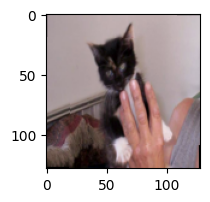

In [4]:
plt.figure(figsize = (2,2))
plt.imshow(train_data[800][0].permute(1,2,0))

In [5]:
#important HyperParameters
batch_size = 32
learning_rate=0.001
minimum_learning_rate=1e-5
epochs = 5

In [6]:
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True,num_workers=2, pin_memory=True)
val_loader = DataLoader(test_data, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)

In [7]:
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR

class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        # Feature extraction layers
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.1),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.3)
        )

        # Classification layers
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((4, 4)),
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

#1. Get the Model
model = CNNModel().to(device)
# 2. Define optimizer
optimizer = Adam(model.parameters(), lr=learning_rate)
# 3. Define LR scheduler
scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=minimum_learning_rate)
# 4. Define loss function
criterion = nn.CrossEntropyLoss()

from torchsummary import summary
summary(model, input_size=(3,size,size));

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
       BatchNorm2d-2         [-1, 32, 128, 128]              64
              ReLU-3         [-1, 32, 128, 128]               0
            Conv2d-4         [-1, 32, 128, 128]           9,248
       BatchNorm2d-5         [-1, 32, 128, 128]              64
              ReLU-6         [-1, 32, 128, 128]               0
         MaxPool2d-7           [-1, 32, 64, 64]               0
         Dropout2d-8           [-1, 32, 64, 64]               0
            Conv2d-9           [-1, 64, 64, 64]          18,496
      BatchNorm2d-10           [-1, 64, 64, 64]             128
             ReLU-11           [-1, 64, 64, 64]               0
           Conv2d-12           [-1, 64, 64, 64]          36,928
      BatchNorm2d-13           [-1, 64, 64, 64]             128
             ReLU-14           [-1, 64,

In [8]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        total_loss += loss.item()

        # compute accuracy
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = total_loss / len(loader)
    train_acc = correct / total

    return train_loss, train_acc

def validate_epoch(model, loader, criterion, device):

    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_loss = total_loss / len(loader)
    val_acc = correct / total

    return val_loss, val_acc

In [9]:
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

for epoch in range(epochs):
    print(f"----------------------------------------------------")
    print(f"Epoch {epoch+1}/{epochs}, LR: {optimizer.param_groups[0]['lr']:.6g}")

    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)
    scheduler.step()

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

----------------------------------------------------
Epoch 1/5, LR: 0.001
Train Loss: 0.6722 | Train Acc: 0.6040
Val Loss: 0.6188 | Val Acc: 0.6426
----------------------------------------------------
Epoch 2/5, LR: 0.000905463
Train Loss: 0.6114 | Train Acc: 0.6627
Val Loss: 0.5696 | Val Acc: 0.6945
----------------------------------------------------
Epoch 3/5, LR: 0.000657963
Train Loss: 0.5846 | Train Acc: 0.6832
Val Loss: 0.5752 | Val Acc: 0.7029
----------------------------------------------------
Epoch 4/5, LR: 0.000352037
Train Loss: 0.5640 | Train Acc: 0.7054
Val Loss: 0.5273 | Val Acc: 0.7217
----------------------------------------------------
Epoch 5/5, LR: 0.000104537
Train Loss: 0.5465 | Train Acc: 0.7233
Val Loss: 0.5083 | Val Acc: 0.7454


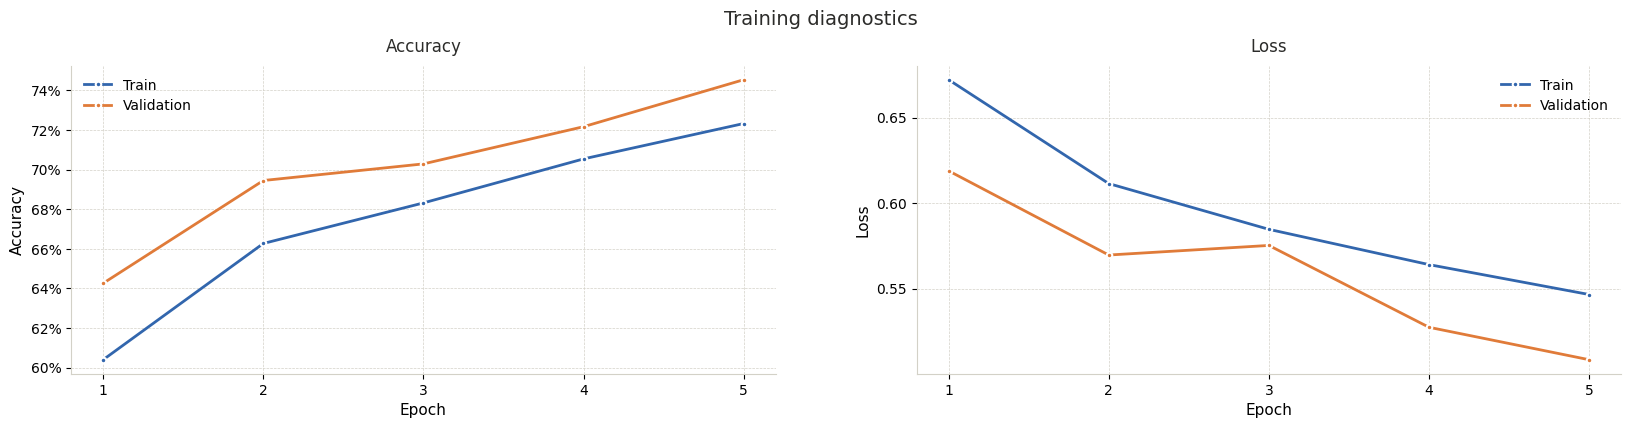

In [10]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import numpy as np

BLUE   = "#3266ad"
ORANGE = "#e07b39"
GRAY   = "#88877f"
BLACK  = "#000000"

plt.rcParams.update({
    "font.family": "sans-serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#d3d1c7",
    "axes.linewidth": 0.8,
    "axes.grid": True,
    "grid.color": "#d3d1c7",
    "grid.linewidth": 0.5,
    "grid.linestyle": "--",
    "xtick.color": BLACK,
    "ytick.color": BLACK,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

epochs_number = np.arange(1, epochs+1)
fig = plt.figure(figsize=(20, 4))
gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.2)

# ── Accuracy ──────────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])
ax1.plot(epochs_number, train_accuracies, color=BLUE,   lw=2,   label="Train",      marker="o", ms=4, mew=1.5, mec="white")
ax1.plot(epochs_number, val_accuracies,   color=ORANGE, lw=2,   label="Validation", marker="o", ms=4, mew=1.5, mec="white", linestyle="-")
ax1.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x*100:.0f}%"))
ax1.set_xlabel("Epoch", color=BLACK, fontsize=11)
ax1.set_ylabel("Accuracy", color=BLACK, fontsize=11)
ax1.set_title("Accuracy", fontsize=12, fontweight="medium", color="#2c2c2a", pad=10)
ax1.legend(frameon=False, fontsize=10, labelcolor=BLACK)

# ── Loss ──────────────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1])
ax2.plot(epochs_number, train_losses, color=BLUE,   lw=2, label="Train",      marker="o", ms=4, mew=1.5, mec="white")
ax2.plot(epochs_number, val_losses,   color=ORANGE, lw=2, label="Validation", marker="o", ms=4, mew=1.5, mec="white", linestyle="-")
ax2.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax2.yaxis.set_major_locator(mticker.MultipleLocator(0.05))
ax2.set_xlabel("Epoch", color=BLACK, fontsize=11)
ax2.set_ylabel("Loss",  color=BLACK, fontsize=11)
ax2.set_title("Loss", fontsize=12, fontweight="medium", color="#2c2c2a", pad=10)
ax2.legend(frameon=False, fontsize=10, labelcolor=BLACK)

fig.suptitle("Training diagnostics", fontsize=14, fontweight="medium", color="#2c2c2a", y=1.02)
plt.savefig("training_curves.pdf", bbox_inches="tight", dpi=150)
plt.show()

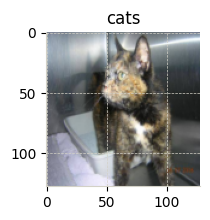

In [11]:
model.eval()
with torch.no_grad():
  ix = torch.randint(0,len(test_data),())
  img = test_data[ix][0].unsqueeze(0).to(device)
  np_output = model(img).cpu().detach().numpy()
  pred = np.exp(np_output)/np.sum(np.exp(np_output))
  plt.figure(figsize=(2,2))
  plt.imshow(img.squeeze(0).permute(1,2,0).cpu().detach().numpy())
  plt.title(train_data.classes[pred[0].argmax()])
  plt.show()

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

class_names = test_data.classes  # from ImageFolder

model.eval()
misclassified = []
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        # Save all predictions and labels for confusion matrix
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        # Store misclassified images
        for img, true, pred in zip(images, labels, preds):
            if true != pred:
                misclassified.append((img.cpu(), true.cpu(), pred.cpu()))

Total misclassified samples: 515


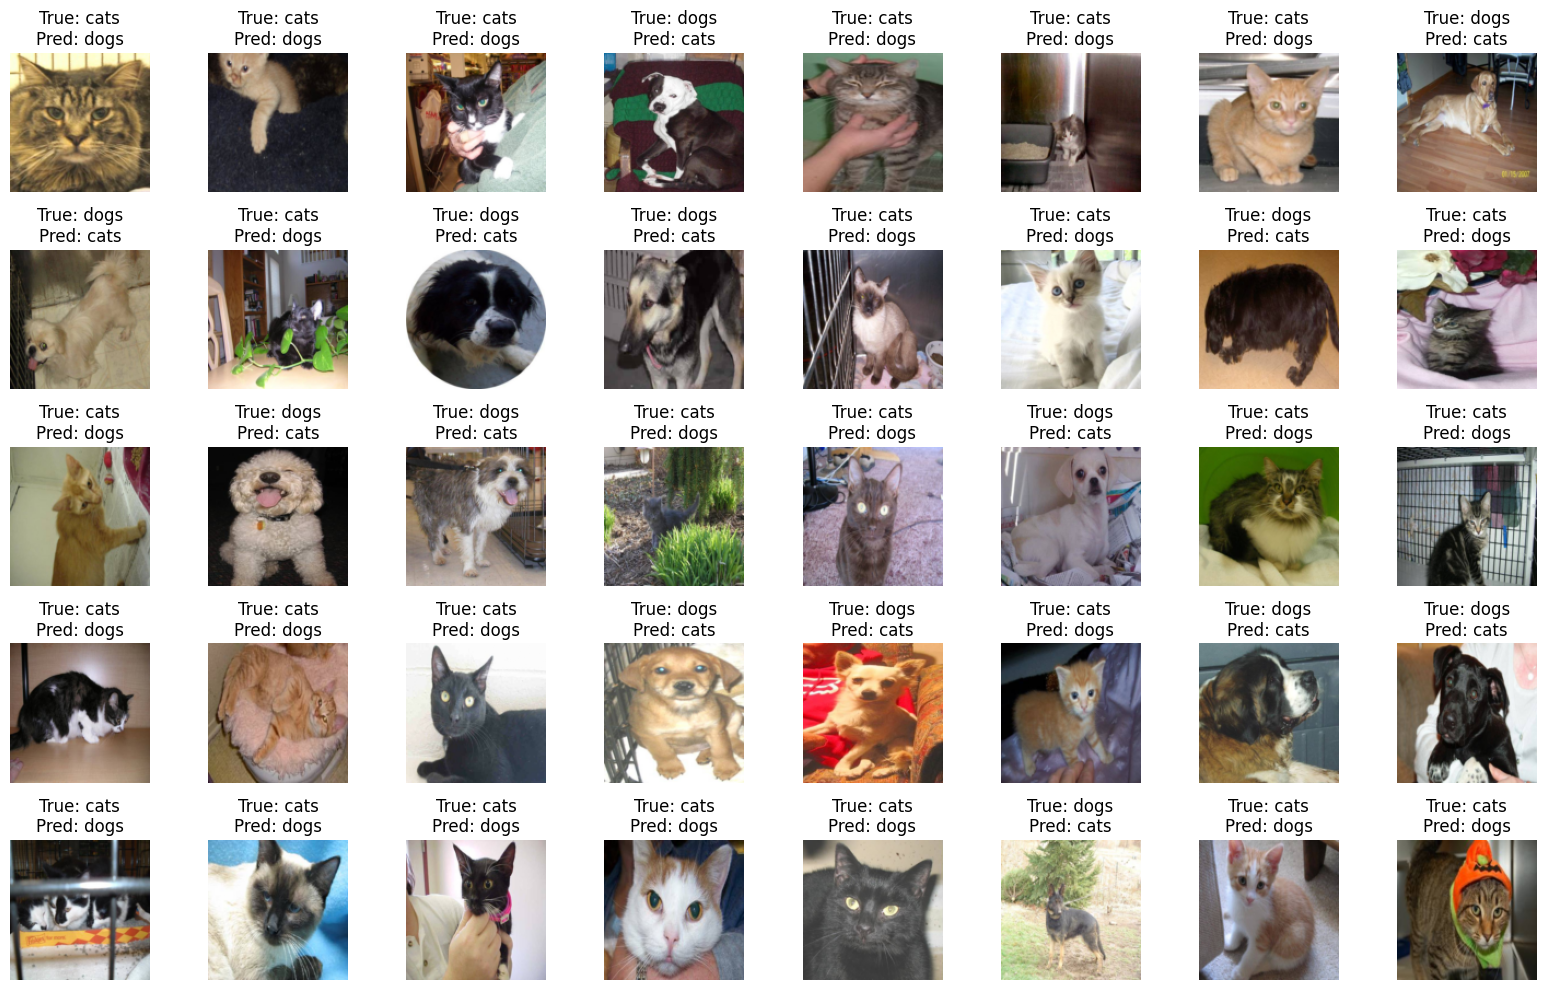

In [13]:
print(f"Total misclassified samples: {len(misclassified)}")
num_rows = 5
num_cols = 8
num_to_show = num_rows * num_cols
num_to_show = min(num_to_show, len(misclassified))

fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols*2, num_rows*2))
axes = axes.flatten()  # flatten for easy iteration

for idx in range(num_to_show):
    img, true, pred = misclassified[idx]
    img = img.permute(1, 2, 0)  # CxHxW -> HxWxC
    axes[idx].imshow(img)
    axes[idx].set_title(f"True: {class_names[true]}\nPred: {class_names[pred]}")
    axes[idx].axis('off')

# Turn off any unused subplots
for idx in range(num_to_show, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

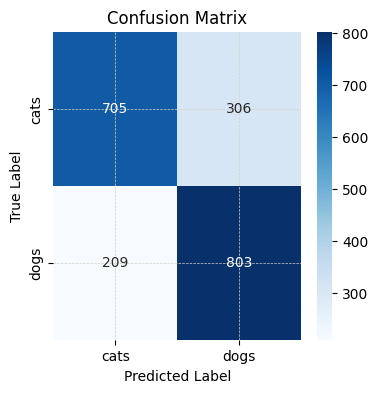

In [14]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(4, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=train_data.classes, yticklabels=train_data.classes)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

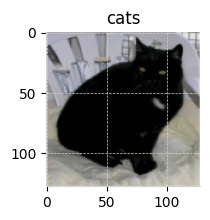

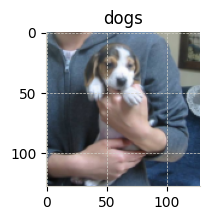

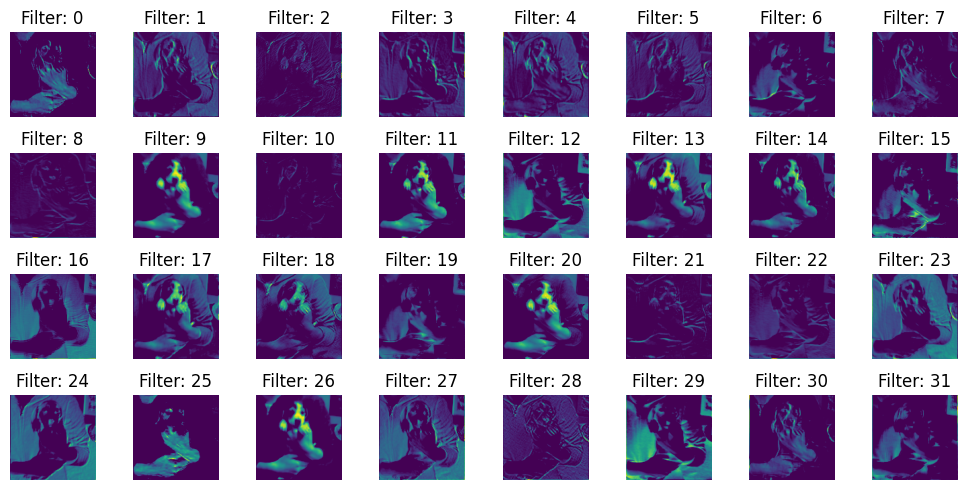

In [38]:
model.eval()
with torch.no_grad():
  ix = 1200
  img = test_data[ix][0].unsqueeze(0).to(device)
  np_output = model(img).cpu().detach().numpy()
  pred = np.exp(np_output)/np.sum(np.exp(np_output))
  plt.figure(figsize=(2,2))
  plt.imshow(img.squeeze(0).permute(1,2,0).cpu().detach().numpy())
  plt.title(train_data.classes[pred[0].argmax()])
  plt.show()

layer = nn.Sequential(*model.features[:3])
intermediate_output = layer(img)

fig, ax = plt.subplots(4, 8, figsize=(10, 5))
for ix, axis in enumerate(ax.flat):
    axis.set_title('Filter: ' + str(ix))
    axis.imshow(intermediate_output[0, ix].cpu().detach().numpy(), cmap='viridis')
    axis.axis('off')
plt.tight_layout()
plt.show()